# AutoSort 训练 Pipeline

主要步骤：
1. 阈值检测
2. 训练数据准备
3. 训练模型


In [1]:
import numpy as np
import pandas as pd
import pickle
import warnings
warnings.filterwarnings('ignore')

import spikeinterface.extractors as se
import spikeinterface.preprocessing as spre

from pathlib import Path
from utils_clean import (
    prepare_training_data,
    train_autosort_model
)


In [2]:
# 加载数据
recording_path = '/media/ubuntu/sda/data/mouse6/ns4/natural_image/mouse6_021322_natural_image_001.ns4'
spike_inf_path = "/media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/kilosort_spike_sorting/sorting_new/021322/spike_inf.tsv"
neuron_inf_path = "/media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/kilosort_spike_sorting/sorting_new/021322/neuron_inf.pkl"

# 加载 GT 数据
spike_inf = pd.read_csv(spike_inf_path, sep='\t', index_col=0)
with open(neuron_inf_path, 'rb') as f:
    neuron_inf = pickle.load(f)

# 加载并预处理 recording
recording_raw = se.read_blackrock(file_path=recording_path)
recording_recorded = recording_raw.remove_channels(["98", '31', '32'])
recording_f = spre.bandpass_filter(recording_recorded, freq_min=300, freq_max=3000)
recording_f = spre.common_reference(recording_f, reference="global", operator="median")

print(f"Recording 加载完成")
print(f"采样率: {recording_f.get_sampling_frequency()} Hz")
print(f"通道数: {recording_f.get_num_channels()}")


Recording 加载完成
采样率: 10000.0 Hz
通道数: 30


## 步骤 1: 阈值检测 + 训练数据准备


In [3]:
# 设置参数
save_dir = "/media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/autosort_input/"
duration_seconds = 200  # 处理时长（秒）

# 检测参数（与 AutoSort 默认值一致）
detection_params = {
    'thr_min': 3.5,
    'thr_max': 30,
    'distance': 3,
    'ch_max_simul_firing': 5,
    'wlen': 5,
    'prominence': 10,
}

# 波形窗口参数
window_params = {
    'left_sample': 10,
    'right_sample': 20,
}

# 准备训练数据（包含阈值检测、GT匹配、波形提取、数据保存）
train_data_dir = prepare_training_data(
    recording_f=recording_f,
    spike_inf=spike_inf,
    neuron_inf=neuron_inf,
    save_dir=save_dir,
    duration_seconds=duration_seconds,
    **detection_params,
    **window_params
)


### 1. 阈值检测
采样率: 10000.0 Hz, 通道数: 30
Recording总长度: 40000100 采样点 (4000.01 秒)
将处理前 2000000 采样点 (200.00 秒)
数据形状: (2000000, 30)
构建 detect_array...
检测到的 spike 数量: 431532

### 2. 加载 Ground Truth 并匹配
构建 gt_array...
GT spike 数量: 74790
---spike detection rate: 0.9266
匹配到的 spike 数量: 69300
未匹配的 spike 数量: 362232

### 3. 提取波形


提取波形: 100%|██████████| 30/30 [00:08<00:00,  3.73it/s]


波形提取完成！
waveform 形状: (431525, 30, 30)

### 4. 保存训练数据
保存目录: /media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/autosort_input/train_data
保存数据...
  ✓ X_waveform.pkl 已保存
  ✓ Y_spike_id.pkl 已保存
  ✓ Y_spike_id_noise.pkl 已保存
  ✓ X_spiketrain_time.pkl 已保存

所有数据已保存到: /media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/autosort_input/train_data
数据统计:
  - 总 spike 数量: 431525
  - 通道数: 30
  - 窗口长度: 30
  - 唯一单元数: 27
  - 噪声 spike 数量: 362227
  - 有效 spike 数量: 69298


## 步骤 2: 训练模型


In [4]:
# 设置训练参数
model_save_dir = save_dir + "model_save/"
n_channels = recording_f.get_num_channels()

training_params = {
    'epochs': 20,
    'batch_size': 512,
    'left_sample': 10,
    'right_sample': 20,
}

# 训练模型
autosort_model, training_log = train_autosort_model(
    train_data_dir=train_data_dir,
    model_save_dir=model_save_dir,
    n_channels=n_channels,
    **training_params
)

print("\n训练完成！")


使用设备: cuda
创建 dataset...
Dataset 加载完成:
  - 总样本数: 431525
  - 通道数: 30
  - 窗口长度: 30
  - 唯一单元数: 27
  - 噪声样本数: 362227.0
  - 非噪声样本数: 69298.0
模型参数:
  - 通道数: 30
  - 窗口长度: 30
  - 单元数量: 27
  - 输入维度: 930

数据集划分:
  - 训练集: 345220 样本
  - 验证集: 86305 样本
已加载现有模型

训练完成！


## 可选：查看训练日志


从文件读取训练日志: /media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/autosort_input/model_save/training_log.csv


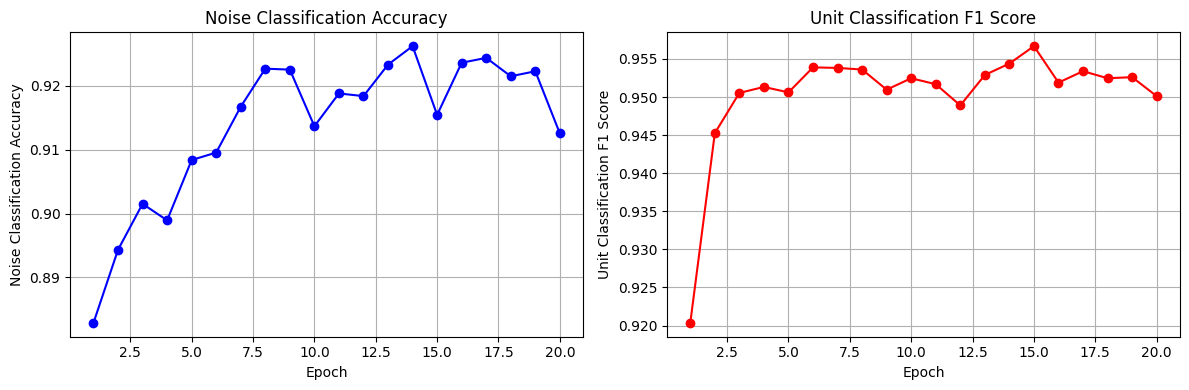


训练日志摘要:
    epoch  validation_acc_noise  validation_acc_label
15     16              0.923620              0.951895
16     17              0.924384              0.953394
17     18              0.921499              0.952466
18     19              0.922287              0.952609
19     20              0.912543              0.950111

完整训练日志路径: /media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/autosort_input/model_save/training_log.csv


In [6]:
# 方式1: 如果刚完成训练，使用 training_log 变量
if training_log is not None:
    log_df = pd.DataFrame(training_log)
else:
    # 方式2: 从文件读取训练日志（如果训练已完成）
    log_path = model_save_dir + 'training_log.csv'
    try:
        log_df = pd.read_csv(log_path, index_col=0)
        print(f"从文件读取训练日志: {log_path}")
    except FileNotFoundError:
        print(f"训练日志文件不存在: {log_path}")
        print("请先运行训练步骤")
        log_df = None

# 可视化训练日志
if log_df is not None:
    import matplotlib.pyplot as plt
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    axes[0].plot(log_df['epoch'], log_df['validation_acc_noise'], 'b-o')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Noise Classification Accuracy')
    axes[0].set_title('Noise Classification Accuracy')
    axes[0].grid(True)
    
    axes[1].plot(log_df['epoch'], log_df['validation_acc_label'], 'r-o')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Unit Classification F1 Score')
    axes[1].set_title('Unit Classification F1 Score')
    axes[1].grid(True)
    
    plt.tight_layout()
    plt.show()
    
    print("\n训练日志摘要:")
    print(log_df.tail())
    
    print(f"\n完整训练日志路径: {model_save_dir}training_log.csv")
